In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("clean_data.csv")
display(df.head(5))

,chenal_group,user,session,engaged_session,avg_eng_time_per_session,engaged_session_per_user,event_per_session,engagement_rate,event_count,date,hour,year,month
0,Direct,237,300,144,47.526667,0.607595,4.673333,0.480000,1402,2024-04-16,23,2024,4
1,Organic Social,208,267,132,32.097378,0.634615,4.295880,0.494382,1147,2024-04-17,19,2024,4
2,Direct,188,233,115,39.939914,0.611702,4.587983,0.493562,1069,2024-04-17,23,2024,4
3,Organic Social,187,256,125,32.160156,0.668449,4.078125,0.488281,1044,2024-04-17,18,2024,4
4,Organic Social,175,221,112,46.918552,0.640000,4.529412,0.506787,1001,2024-04-17,20,2024,4


In [3]:
df.describe()

,user,session,engaged_session,avg_eng_time_per_session,engaged_session_per_user,event_per_session,engagement_rate,event_count,hour,year,month
count,3182.000000,3182.000000,3182.000000,3182.000000,3182.000000,3182.000000,3182.000000,3182.000000,3182.000000,3182.0,3182.000000
mean,41.935889,51.192646,28.325581,66.644581,0.606450,4.675969,0.503396,242.272470,11.807040,2024.0,4.108108
std,29.582258,36.919962,20.650569,127.200659,0.264023,2.795228,0.228206,184.440313,6.886686,0.0,0.310566
min,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,2024.0,4.000000
25%,20.000000,24.000000,13.000000,32.103034,0.561404,3.750000,0.442902,103.000000,6.000000,2024.0,4.000000
50%,42.000000,51.000000,27.000000,49.020202,0.666667,4.410256,0.545455,226.000000,12.000000,2024.0,4.000000
75%,60.000000,71.000000,41.000000,71.487069,0.750000,5.217690,0.633333,339.000000,18.000000,2024.0,4.000000
max,237.000000,300.000000,144.000000,4525.000000,2.000000,56.000000,1.000000,1402.000000,23.000000,2024.0,5.000000


<Axes: >

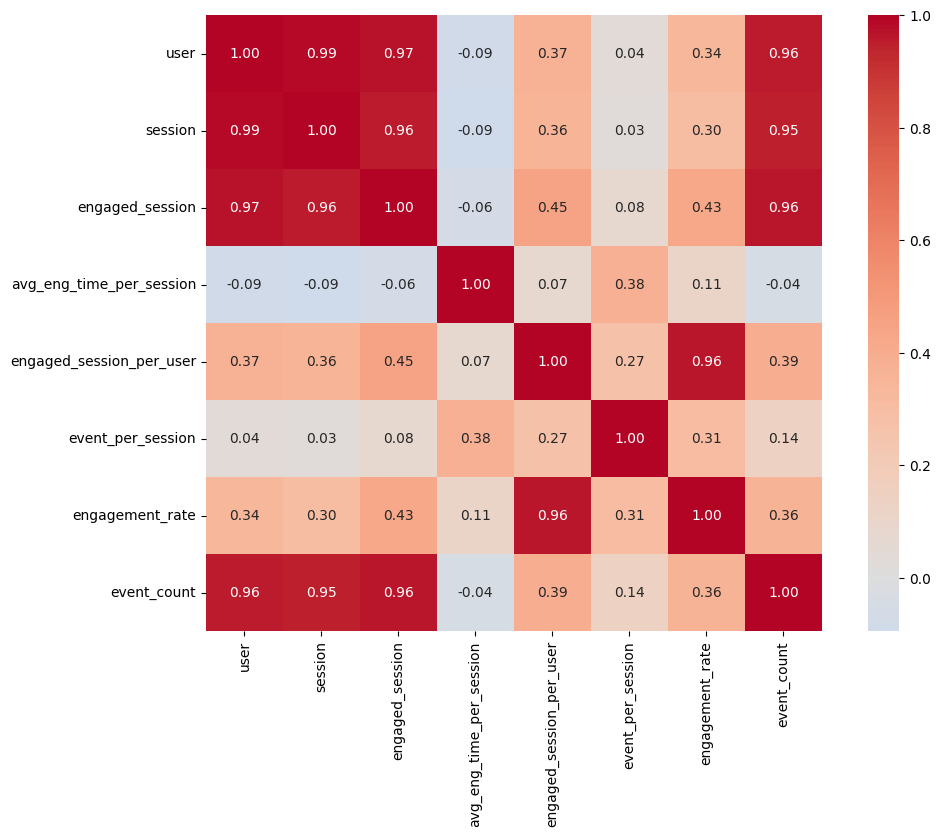

In [4]:
numeric_cols = df.select_dtypes(np.number)
numeric_cols = numeric_cols.drop(columns=['hour' , 'month' , 'year'])
plt.figure(figsize=(12, 8))
sns.heatmap(data=numeric_cols.corr() ,annot=True ,cmap='coolwarm' , center=0 , square=True ,  fmt=".2f")

* user, session, engaged_session, and event_count are highly correlated.

* engagement_rate is strongly tied to engaged_session_per_user and engagement_rate.

* avg_eng_time_per_session has weak correlations with most other metrics.

1 . what pattern and trend can you observe in websiite session and user over time?

In [5]:
from scipy.stats import pearsonr
col = ['user' ,'session']
correlations = []
for col in col:
    corr, p_value = pearsonr(df[col], df['hour'])
    correlations.append({
        'column': col,
        'Correlation': round(corr, 4),
        'P-value': round(p_value, 4)
    })

corr_df = pd.DataFrame(correlations).sort_values(by='Correlation', ascending=False)
display(corr_df)

,column,Correlation,P-value
0,user,0.3325,0.0
1,session,0.2904,0.0


In [6]:
df['date'] = pd.to_datetime(df['date'])
df['week'] = df['date'].dt.isocalendar().week
df['day_of_week'] = df['date'].dt.day_name()
hour_pattern = df.groupby(["hour"]).agg(
    session= ("session" , sum),
    user = ("user" , "sum")
)

week_pattern = df.groupby("day_of_week").agg(
    session = ("session" , "sum"),
    user = ('user' , "sum")
).reindex(['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])
display(hour_pattern)
display(week_pattern)

,session,user
hour,,
0,8148,5864
1,5228,4011
2,3999,3167
3,3199,2531
4,2786,2234
5,2598,2093
6,3161,2551
7,3946,3176
8,4781,3855


,session,user
day_of_week,,
Monday,24111,19774
Tuesday,23869,19574
Wednesday,25344,20691
Thursday,24751,20416
Friday,24941,20484
Saturday,19702,16034
Sunday,20177,16467


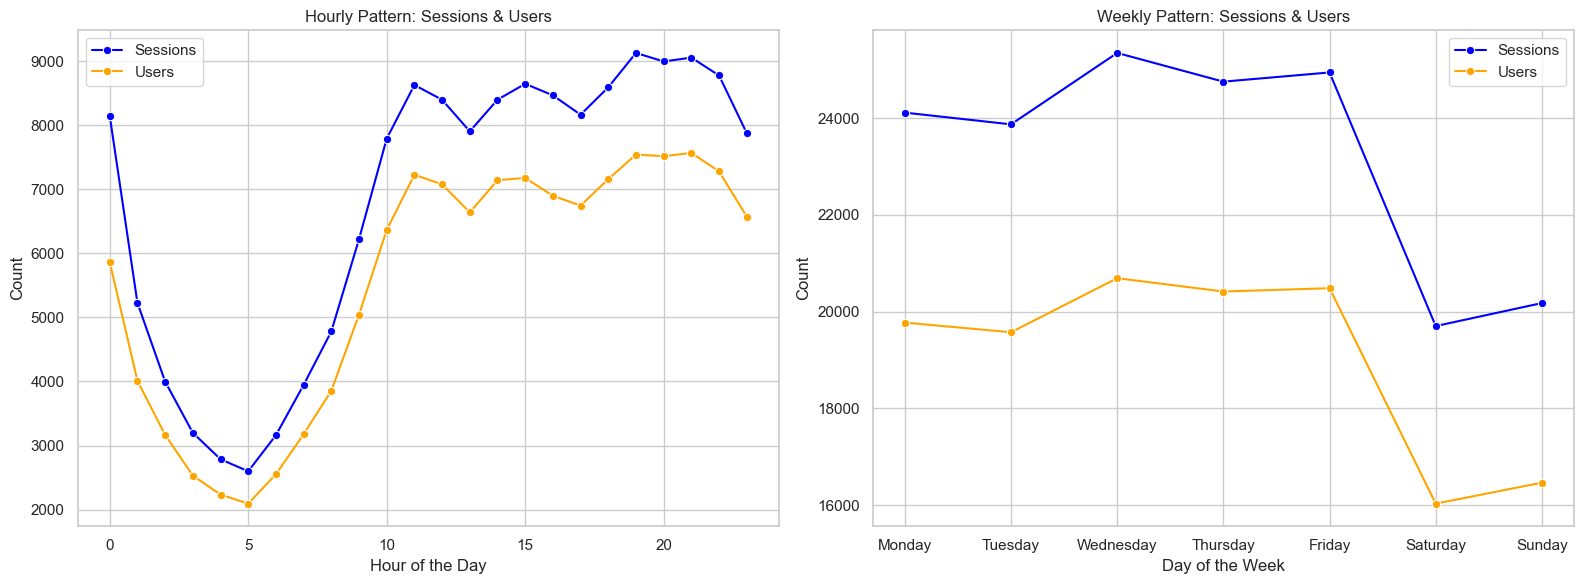

In [7]:
# Set the style for better aesthetics
sns.set(style="whitegrid")

# Create a figure with 1 row and 2 columns
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot hourly pattern
sns.lineplot(
    data=hour_pattern,
    x=hour_pattern.index,
    y="session",
    ax=axes[0],
    label="Sessions",
    marker="o",
    color="blue"
)
sns.lineplot(
    data=hour_pattern,
    x=hour_pattern.index,
    y="user",
    ax=axes[0],
    label="Users",
    marker="o",
    color="orange"
)
axes[0].set_title("Hourly Pattern: Sessions & Users")
axes[0].set_xlabel("Hour of the Day")
axes[0].set_ylabel("Count")
axes[0].legend()

# Plot weekly pattern
sns.lineplot(
    data=week_pattern,
    x=week_pattern.index,
    y="session",
    ax=axes[1],
    label="Sessions",
    marker="o",
    color="blue"
)
sns.lineplot(
    data=week_pattern,
    x=week_pattern.index,
    y="user",
    ax=axes[1],
    label="Users",
    marker="o",
    color="orange"
)
axes[1].set_title("Weekly Pattern: Sessions & Users")
axes[1].set_xlabel("Day of the Week")
axes[1].set_ylabel("Count")
axes[1].legend()

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

2 . which marketing chennal brought higest no of user to the website and how can we use this insight to improve traffic from other source?

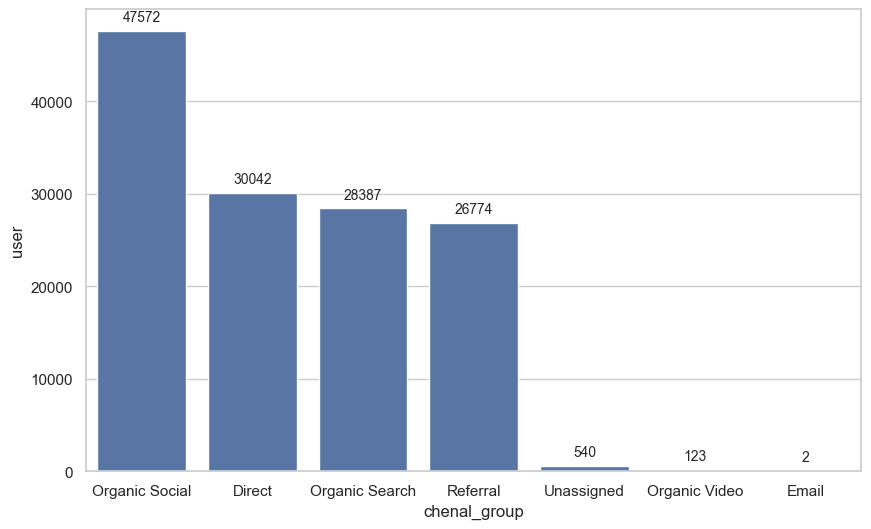

In [8]:
highest_user = df.groupby('chenal_group').agg(
    user = ('user' , 'sum')
).sort_values(by='user' , ascending=False)
# display(highest_user)
plt.figure(figsize=(10,6))
ax = sns.barplot(data=highest_user , x='chenal_group' , y='user')
for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f'{int(height)}',
        (p.get_x() + p.get_width() / 2., height),
        ha='center',
        va='bottom',
        fontsize=10,
        xytext=(0, 5),
        textcoords='offset points'
    )
plt.show()

3 . which chennal has higest avg_engagement time , and what does that tell us about user behaviour and content effectiveness?

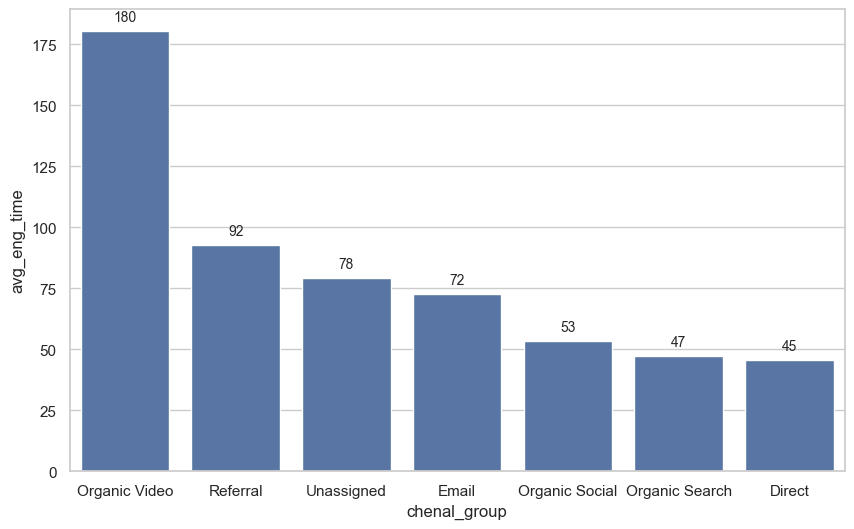

In [9]:
engaggement_session = df.groupby('chenal_group').agg(
    avg_eng_time = ("avg_eng_time_per_session" , "mean")
).sort_values(by='avg_eng_time' , ascending=False)
engaggement_session = engaggement_session.round(2)
# display(engaggement_session)
plt.figure(figsize=(10,6))
ax = sns.barplot(data=engaggement_session , x='chenal_group' , y='avg_eng_time')
for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f'{int(height)}',
        (p.get_x() + p.get_width() / 2., height),
        ha='center',
        va='bottom',
        fontsize=10,
        xytext=(0, 5),
        textcoords='offset points'
    )
plt.show()

4 . how does engagemet rate vary accross diffrent chenal?

,avg_eng_rate(%)
chenal_group,
Organic Video,76.00
Referral,66.09
Organic Search,57.89
Organic Social,54.12
Direct,45.57
Email,33.33
Unassigned,0.75


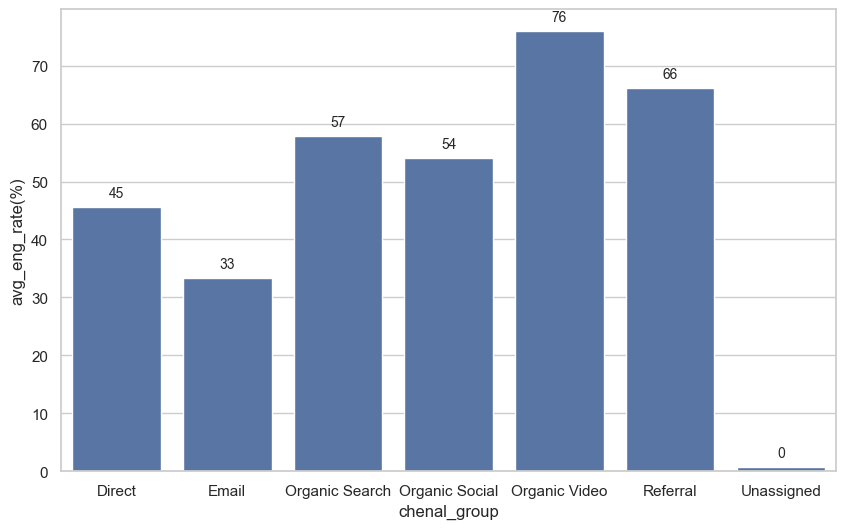

In [10]:
engage_rate = df.groupby('chenal_group')['engagement_rate'].agg(['mean']).rename(columns={'mean' : "avg_eng_rate(%)"})
engage_rate['avg_eng_rate(%)'] = (engage_rate['avg_eng_rate(%)'] * 100).round(2)
display(engage_rate.sort_values(by='avg_eng_rate(%)' , ascending=False))

plt.figure(figsize=(10,6))
ax = sns.barplot(data=engage_rate , x='chenal_group' , y='avg_eng_rate(%)')
for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f'{int(height)}',
        (p.get_x() + p.get_width() / 2., height),
        ha='center',
        va='bottom',
        fontsize=10,
        xytext=(0, 5),
        textcoords='offset points'
    )
plt.show()

In [11]:
weighted = df.groupby('chenal_group').apply(
    lambda x: (x['engagement_rate'] * x['session']).sum() / x['session'].sum() * 100
).round(2).reset_index()
weighted.columns = ['chenal_group', 'weighted_avg_eng_rate_%']
display(weighted.sort_values(by='weighted_avg_eng_rate_%' , ascending=False))

comparison = pd.merge(engage_rate, weighted, on='chenal_group')
comparison = comparison.sort_values(by='weighted_avg_eng_rate_%', ascending=False)
display(comparison)

,chenal_group,weighted_avg_eng_rate_%
4,Organic Video,77.30
5,Referral,66.64
2,Organic Search,58.21
3,Organic Social,53.93
0,Direct,46.35
1,Email,33.33
6,Unassigned,0.72


,chenal_group,avg_eng_rate(%),weighted_avg_eng_rate_%
4,Organic Video,76.00,77.30
5,Referral,66.09,66.64
2,Organic Search,57.89,58.21
3,Organic Social,54.12,53.93
0,Direct,45.57,46.35
1,Email,33.33,33.33
6,Unassigned,0.75,0.72


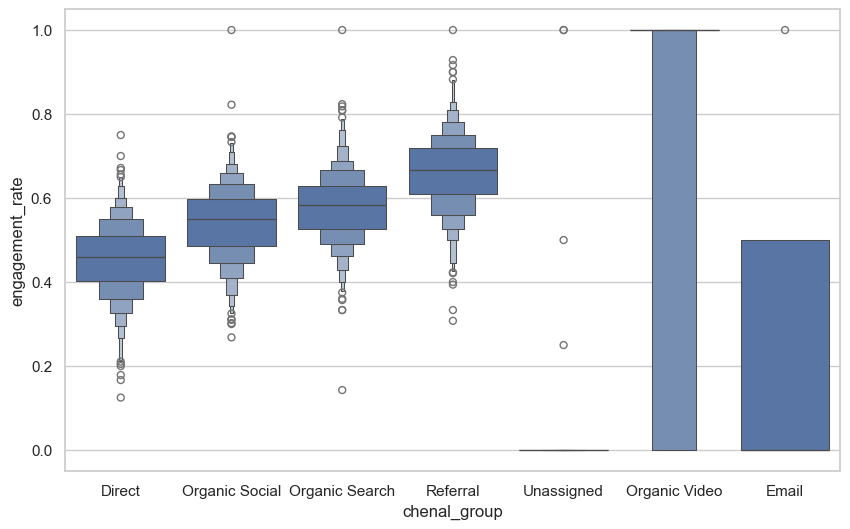

In [12]:
plt.figure(figsize=(10,6))
sns.boxenplot(data = df , x="chenal_group" , y = "engagement_rate")
plt.show()

1 . Focus on Organic Video:

This channel has near-perfect engagement. Investigate what makes it successful and replicate those strategies elsewhere.

2 . Improve Direct Traffic:

Direct traffic has the lowest engagement. Audit the user experience (UX) for direct visitors (e.g., landing pages, CTAs).

3 . Optimize Referral and Unassigned:

These channels have high variability. Identify top-performing referrals and unassigned sources to double down on what works.

4 . Leverage Email:

Email has consistent engagement. Use it for targeted campaigns to boost other channels.

5 . Monitor Organic Social:

Engagement is moderate but inconsistent. Test different content types (e.g., videos, images) to improve consistenc

5 . which chennal are driving more engaged session compared to non-engaged ones,and what stretagie can improve engagement in underperforming chanels???   

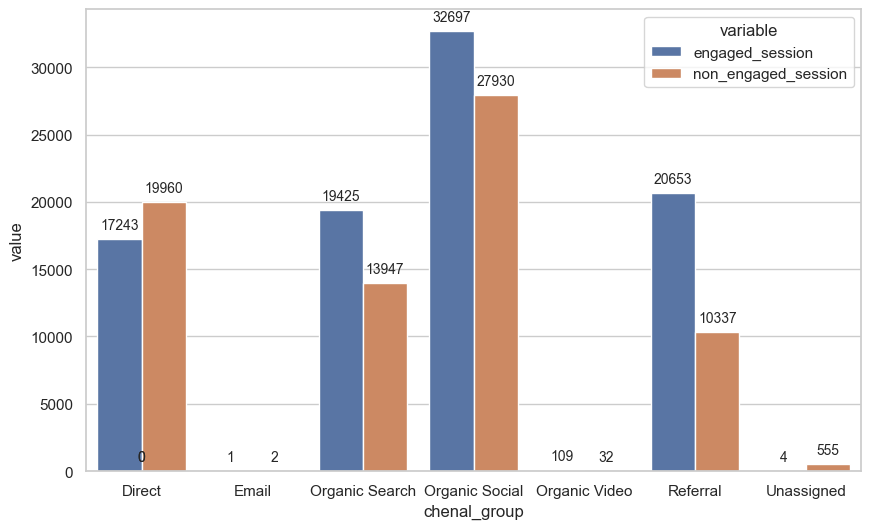

In [13]:
session_df = df.groupby('chenal_group').agg(
    session=('session', 'sum'),
    engaged_session=('engaged_session', 'sum')
).reset_index()

# Calculate non-engaged sessions
session_df['non_engaged_session'] = session_df['session'] - session_df['engaged_session']

# Melt the DataFrame for visualization
session_df_show = session_df.melt(
    id_vars='chenal_group',  # Corrected column name
    value_vars=['engaged_session', 'non_engaged_session']  # Corrected column name
)

# Display the result
# display(session_df_show)
plt.figure(figsize=(10,6))
ax = sns.barplot(data=session_df_show , x = "chenal_group" , y="value" , hue='variable')
for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f'{int(height)}',
        (p.get_x() + p.get_width() / 2., height),
        ha='center',
        va='bottom',
        fontsize=10,
        xytext=(0, 5),
        textcoords='offset points'
    )
plt.show()

6 . at what hour of day does each chenal drive most traffic?

In [14]:
traffic_by_hour = df.groupby(['chenal_group', 'hour']).agg(
    total_sessions=('session', 'sum'),
    total_users=('user', 'sum'),
    total_events=('event_count', 'sum')
).reset_index()

peack_hour = traffic_by_hour.loc[traffic_by_hour.groupby('chenal_group')['total_sessions'].idxmax()]
peack_hour.sort_values(by='total_sessions' , ascending=False)
display(peack_hour)
# display(peack_hour[['chenal_group','hour' ,'total_sessions','total_users' , 'total_events' ]])

,chenal_group,hour,total_sessions,total_users,total_events
23,Direct,23,2581,2129,11255
24,Email,2,1,1,5
41,Organic Search,14,1964,1710,8063
51,Organic Social,0,3917,2565,16282
94,Organic Video,19,12,11,57
120,Referral,21,1799,1587,10158
138,Unassigned,15,38,38,117


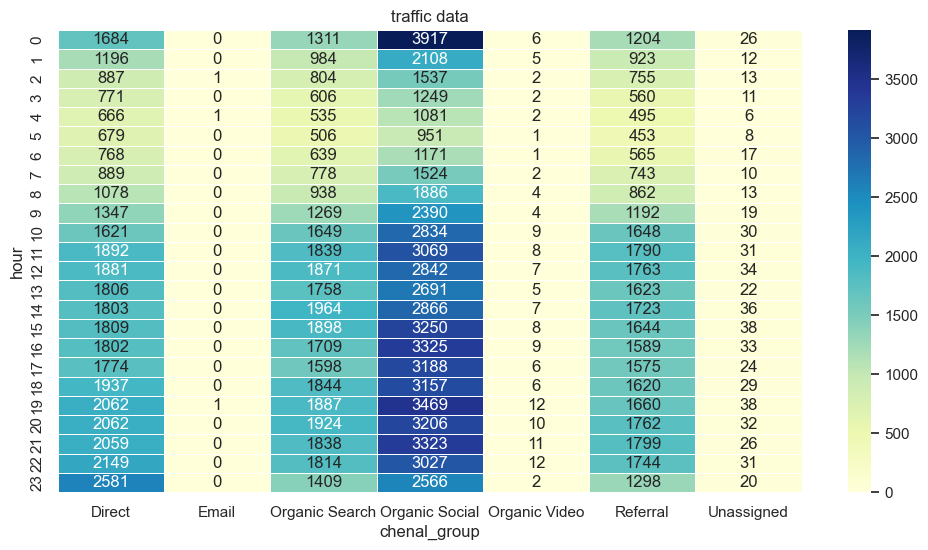

In [21]:
heatmap_show = df.groupby(['hour' , 'chenal_group'])['session'].sum().unstack().fillna(0)
plt.figure(figsize=(12,6))
sns.heatmap(heatmap_show , annot=True , fmt='.0f' , linewidths=0.5 , cmap='YlGnBu')
plt.title('traffic data')
plt.xlabel('chenal_group')
plt.ylabel('hour')
plt.show()

7. is there any corelation between high traffic(session) and high engagement rate over a time ?  

In [45]:
from scipy.stats import pearsonr
df['date'] = pd.to_datetime(df['date'])
col = ['session' ,'engagement_rate']
correlations = []
for col in col:
    corr, p_value = pearsonr(df['session'] , df['engagement_rate'])
    correlations.append({
        'column': col,
        'Correlation': round(corr, 4),
        'P-value': round(p_value, 4)
    })


corr_df = pd.DataFrame(correlations).sort_values(by='Correlation', ascending=False)
display(corr_df)

,column,Correlation,P-value
0,session,0.3034,0.0
1,engagement_rate,0.3034,0.0


corr_hourly : -0.09182013028668869
p_value_hourly : 0.6695868993841365


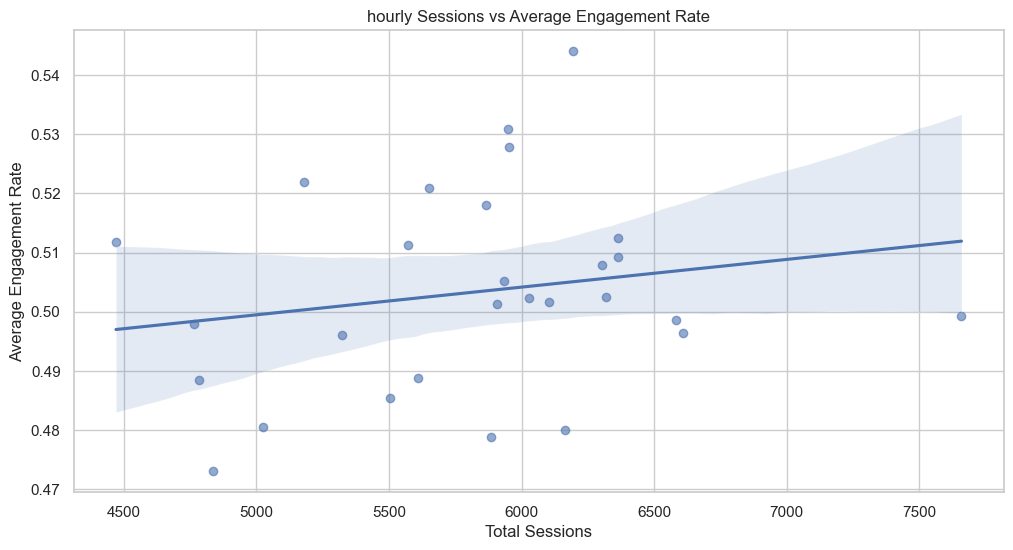

In [56]:
hourly = df.groupby('hour').agg({
    'session' : "sum",
    'engagement_rate' : 'mean'
}
).reset_index()

daily = df.groupby('date').agg({
    'session' : "sum",
    'engagement_rate' : 'mean'
}
).reset_index()

corr_hourly, p_hourly = pearsonr(hourly['session'], hourly['engagement_rate'])
print(f"corr_hourly : {corr_hourly}\np_value_hourly : {p_hourly}")

# Scatter plot - Daily
plt.figure(figsize=(12, 6))
sns.regplot(data=daily, x='session', y='engagement_rate', scatter_kws={'alpha':0.6})
plt.title('hourly Sessions vs Average Engagement Rate')
plt.xlabel('Total Sessions')
plt.ylabel('Average Engagement Rate')
plt.grid(True)
plt.show()